# Actividad 4 Parte 1

## Preparacion de datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

df_crud = pd.read_csv("../DataSets/car_prices.csv")
 
print(f"Filas originales : {len(df_crud):,}")

cols = ["mmr", "odometer", "sellingprice"]
df = df_crud[cols].dropna()
 
print(f"Filas tras limpiar nulos: {len(df):,}")
print("\nEstadísticos descriptivos:")
display(df.describe())

Filas originales : 558,837
Filas tras limpiar nulos: 558,705

Estadísticos descriptivos:


,mmr,odometer,sellingprice
count,558705.000000,558705.000000,558705.000000
mean,13770.846869,68323.830415,13612.941760
std,9679.645290,53398.133653,9749.387229
min,25.000000,1.000000,1.000000
25%,7100.000000,28374.000000,6900.000000
50%,12250.000000,52257.000000,12100.000000
75%,18300.000000,99114.000000,18200.000000
max,182000.000000,999999.000000,230000.000000


## Análisis exploratorio

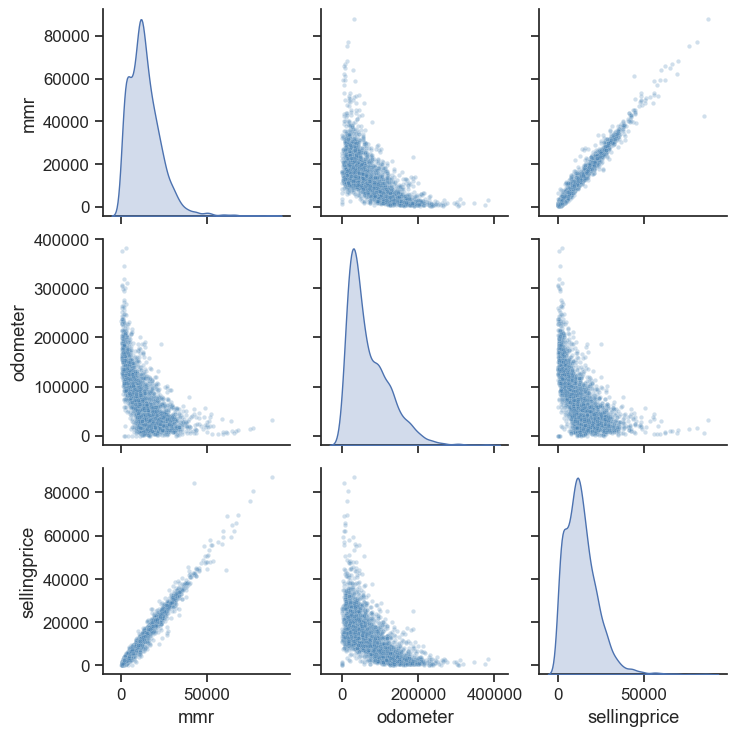

In [6]:
df_sample = df.sample(n=3_000, random_state=42)

pair_fig = sns.pairplot(
    df_sample,
    vars=["mmr", "odometer", "sellingprice"],
    diag_kind="kde",
    plot_kws={"alpha": 0.25, "s": 10, "color": "steelblue"},
)


## Divicion de datos

In [20]:
X = df[["mmr", "odometer"]]
y = df["sellingprice"] 

 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
print(f"Entrenamiento: {len(X_train)} | Prueba: {len(X_test)}")
 
modelo = LinearRegression()
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)
print(f"Ecuación: R = {modelo.intercept_} + {modelo.coef_[0]} * MMR + {modelo.coef_[1]} * Odómetro")

Entrenamiento: 446964 | Prueba: 111741
Ecuación: R = 84.48350933702386 + 0.9875441328896546 * MMR + -0.001040379487200926 * Odómetro


In [ ]:
y_pred_train = modelo.predict(X_train)
y_pred_test = modelo.predict(X_test)
 
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test,  y_pred_test)
 
print(f"R² en entrenamiento : {r2_train:.4f}  ({r2_train*100:.2f} %)")
print(f"R² en prueba: {r2_test:.4f}  ({r2_test*100:.2f} %)")

  R² en entrenamiento : 0.9674  (96.74 %)
  R² en prueba        : 0.9683  (96.83 %)


In [ ]:
pred_df = X_test.head(10).copy()
pred_df["precio_real"] = y_test.head(10).values
pred_df["precio_predicho"] = modelo.predict(X_test.head(10))
pred_df["error"] = (pred_df["precio_predicho"] - pred_df["precio_real"])
print(pred_df.to_string(index=False))

    mmr  odometer  precio_real  precio_predicho        error
 4475.0  132314.0       5000.0      4366.086733  -633.913267
 6850.0  124984.0       4900.0      6719.130030  1819.130030
14400.0   49212.0      16600.0     14253.919868 -2346.080132
24300.0   79806.0      26750.0     23998.777413 -2751.222587
 9975.0   45019.0       9800.0      9888.399391    88.399391
26400.0   46941.0      26500.0     26106.812164  -393.187836
 1650.0  209369.0       1700.0      1496.108116  -203.891884
12150.0   51869.0      13900.0     12029.181280 -1870.818720
29200.0   13418.0      32000.0     28906.812378 -3093.187622
16300.0   49428.0      17250.0     16130.028998 -1119.971002


In [ ]:
mse  = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
mae  = np.mean(np.abs(y_test.values - y_pred_test))
 
print(f"  MSE (Error Cuadrático Medio): {mse:,.2f}")
print(f"  RMSE (Raíz del MSE): {rmse:,.2f}  USD")
print(f"  MAE (Error Absoluto Medio): {mae:,.2f}  USD")
print(f"  Precio promedio en datos de prueba: {y_test.mean():,.2f}  USD")
print(f"  RMSE / Promedio: {rmse/y_test.mean()*100:.2f} %")

  MSE  (Error Cuadrático Medio): 2,998,743.32
  RMSE (Raíz del ECM): 1,731.69  USD
  MAE  (Error Absoluto Medio): 1,090.12  USD
  Precio promedio en datos de prueba: 13,612.11  USD
  RMSE / Promedio: 12.72 %


# Concluciones

Relacion entre variables
- MMR vs precio
    - Relación fuertemente lineal y positiva.
- Odometro vs precio
    - Relación negativa pero es menos fuerte y más dispersa que MMR.
- MMR vs odómetro
    - Relación negativa leve

Interpretación del modelo
```
R=84.48+0.9875⋅MMR−0.00104⋅Odometro
```
- Por cada $1 en MMR, el precio sube casi $1
- Por cada km, el precio baja un poco (0.00104)

- El modelo explica casi todo el comportamiento del precio(R² ≈ 96.8%)
